In [1]:
import json
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.special import stirling2
import math
from copy import copy

In [2]:
status_codes = {
    1: 'LOADED',
    2: 'OPTIMAL',
    3: 'INFEASIBLE',
    4: 'INF_OR_UNBD',
    5: 'UNBOUNDED',
    6: 'CUTOFF',
    7: 'ITERATION_LIMIT',
    8: 'NODE_LIMIT',
    9: 'TIME_LIMIT',
    10: 'SOLUTION_LIMIT',
    11: 'INTERRUPTED',
    12: 'NUMERIC',
    13: 'SUBOPTIMAL',
    14: 'INPROGRESS',
    15: 'USER_OBJ_LIMIT'
}

In [3]:
rng = np.random.default_rng(643)

# SDP Minimal Working Example

# Multivariate utils

In [4]:
def compute_order(alpha):
    '''Sum of elements of a power.'''
    order = 0
    for alpha_i in alpha:
        order += alpha_i
    return order

def compute_Nd(S, d):
    '''Number of moments of order <= d (S species)'''
    Nd = math.factorial(S + d) // (math.factorial(d) * math.factorial(S))
    return Nd

def compute_powers(S, d):
    '''Compute the Nd powers of order <= d (S species)'''

    # all powers
    powers = [[0 for s in range(S)]]

    # powers of order d = 0
    powers_prev = [[0 for s in range(S)]]

    # for order d = 1, ..., d
    for order in range(1, d + 1):

        # store powers of order d
        powers_current = []

        # for each power of order d - 1
        for alpha in powers_prev:

            # for each index
            for i in range(S):

                # add 1 to power at index
                alpha_new = copy(alpha)
                alpha_new[i] += 1

                # store (avoid repeats)
                if alpha_new not in powers_current:
                    powers_current.append(alpha_new)

        # update d - 1 powers
        powers += powers_current

        # update overall powers
        powers_prev = powers_current

    return powers

def add_powers(*powers, S):
    '''Add powers (lists) of size S.'''
    plus = [0 for i in range(S)]
    for i in range(S):
        for power in powers:
            plus[i] += power[i]
    return plus

def falling_factorial(n, k):
    '''FF(n,k) = n(n-1) ... (n - k + 1).'''
    val = 1
    for i in range(k):
        val *= (n - i)
    return val

def binomial_moment(n, p, l):
    '''For X ~ Bin(n, p) compute E[X^l].'''
    val = 0
    for k in range(l + 1):
        val += falling_factorial(n, k) * stirling2(l, k) * p**k
    return val

# Bootstrap

In [5]:
def bootstrap(sample, d, resamples=None):
    '''
    Compute confidence intervals on the moments of a sample of count pairs, use
    resamples number of bootstrap resamples (default to sample size) and estimate
    moments up to order d.

    Args:
        sample: list of tuples (x1, x2) of integer counts per cell
        d: maximum moment order to estimate
        resamples: integer number of bootstrap resamples to use

    Returns:
        (2 x Nd) numpy array of CI bounds on each Nd moment of order <= d
    '''

    # get sample size
    n = len(sample)

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n

    # helpful values
    powers = compute_powers(S=2, d=d)
    Nd = compute_Nd(S=2, d=d)

    # initialize random generator
    rng = np.random.default_rng()

    # convert string to tuple if neccessary (pandas reading csv to string)
    #if type(sample[0]) == str:
    #    sample = [literal_eval(count_pair) for count_pair in sample]

    # separate sample pairs
    x1_sample = [x[0] for x in sample]
    x2_sample = [x[1] for x in sample]

    # convert sample to n x 2 array
    sample = np.array([x1_sample, x2_sample]).T

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # split into 2 N x n arrays
    x1_boot = boot[:, :, 0]
    x2_boot = boot[:, :, 1]

    # estimate
    moment_bounds = np.zeros((2, Nd))
    for i, alpha in enumerate(powers):

        # raise boot to powers
        x1_boot_alpha = x1_boot**alpha[0]
        x2_boot_alpha = x2_boot**alpha[1]

        # multiply (N x n)
        boot_alpha = x1_boot_alpha * x2_boot_alpha

        # mean over sample axis (N x 1)
        moment_estimates = np.mean(boot_alpha, axis=1)

        # quantile over boot axis (2 x 1)
        moment_interval = np.quantile(moment_estimates, [0.025, 0.975])

        # store
        moment_bounds[:, i] = moment_interval

    return moment_bounds

# Downsampling

In [6]:
def downsample_data(sample, mean_capture):

    n = len(sample)

    b = (1 / mean_capture) - 1

    # capture efficiency
    if b == 0:
        beta = np.ones(n)
    else:
        beta = rng.beta(1, b, size=1000)

    # split
    x1_sample = [x[0] for x in sample]
    x2_sample = [x[1] for x in sample]

    # downsample
    x1_downsample = rng.binomial(x1_sample, beta).tolist()
    x2_downsample = rng.binomial(x2_sample, beta).tolist()

    # combine
    downsample = list(zip(x1_downsample, x2_downsample))

    return downsample, beta

# Moment equations

In [7]:
def compute_A(alpha, reactions, vrs, db, R, S, d):
    '''
    Moment equation coefficient matrix
    NOTE: must have order of alpha <= d

    Args:
        alpha: moment order for equation (d/dt mu^alpha = 0)
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: list of lists detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        d: maximum moment order used (must be >= order(alpha) + db - 1)

    Returns:
        A: (R, Nd) matrix of coefficients
    '''

    if compute_order(alpha) > d - db + 1:
        raise NotImplementedError(f"Maximum moment order {d} too small for moment equation of alpha = {alpha}: involves moments of higher order.")

    xs = sp.symbols([f'x{i}' for i in range(S)])

    # reaction propensity polynomials
    # props = [eval(str_ar) for str_ar in reactions]
    props = [sp.parse_expr(str_ar, {'xs': xs}) for str_ar in reactions]

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # get powers of order <= d
    powers = compute_powers(S, d)

    # setup matrix
    A = np.zeros((R, Nd))

    for r, prop in enumerate(props):

        # expand b(x) * ((x + v_r)**alpha - x**alpha)
        term_1 = 1
        term_2 = 1
        for i in range(S):
            term_1 = term_1 * (xs[i] + vrs[r][i])**alpha[i]
            term_2 = term_2 * xs[i]**alpha[i]
        poly = sp.Poly(prop * (term_1 - term_2), xs)

        # loop over terms
        for xs_power, coeff in zip(poly.monoms(), poly.coeffs()):

            # get matrix index
            col = powers.index(list(xs_power))

            # store
            A[r, col] = coeff

    return A

# B Capture matrix

In [8]:
def compute_B(beta, S, U, d):
    '''
    Capture efficiency moment scaling matrix

    Args:
        beta: per cell capture efficiency sample
        S: number of species
        U: unobserved species indices
        d: maximum moment order used

    Returns:
        B: (Nd, Nd) matrix of coefficients
    '''

    # number of moments of order <= d
    Nd = compute_Nd(S, d)

    # compute powers of order <= d
    powers = compute_powers(S, d)

    # compute beta moments of order <= d
    y_beta = np.zeros(d + 1)
    for l in range(d + 1):
        y_beta[l] = np.mean(beta**l)

    # setup matrix
    B = np.zeros((Nd, Nd))

    p = sp.Symbol('p')
    xs = sp.symbols([f'x{i}' for i in range(S)])

    # for each moment power
    for row, alpha in enumerate(powers):

        # setup polynomail
        poly_alpha = 1

        # for each species
        for i in range(S):

            # unobserved: no capture efficiency
            if i in U:
                moment = xs[i]**alpha[i]

            # observed: compute moment expression for E[Xi^alphai] in xi
            else:
                moment = binomial_moment(xs[i], p, alpha[i])
            
            poly = sp.Poly(moment, p, xs[i])

            # multiply
            poly_alpha = poly_alpha * poly

        # loop over terms
        for (beta_power, *xs_power), coeff in zip(poly_alpha.monoms(), poly_alpha.coeffs()):

            # get matrix index
            col = powers.index(xs_power)

            B[row, col] += coeff * y_beta[beta_power]

    return B

# Moment matrices

In [9]:
def construct_M_s(y, s, S, d):
    '''Moment matrix variable constructor (s).'''
    if s == 0:
        D = math.floor(d / 2)
    else:
        D = math.floor((d - 1) / 2)
    powers_D = compute_powers(S, D)
    powers_d = compute_powers(S, d)
    ND = compute_Nd(S, D)
    M_s = [[0 for j in range(ND)] for i in range(ND)]
    e_s = [1 if i == (s - 1) else 0 for i in range(S)]
    for alpha_index, alpha in enumerate(powers_D):
        for beta_index, beta in enumerate(powers_D):
            plus = add_powers(alpha, beta, e_s, S=S)
            plus_index = powers_d.index(plus)
            M_s[alpha_index][beta_index] = y[plus_index].item()
    M_s = gp.MVar.fromlist(M_s)
    return M_s

# NLP base model

In [10]:
def base_model(model, OB_bounds, beta, reactions, vrs, db, R, S, U, d, d_bd, d_me, d_sd, constraints, fixed=[], time_limit=300, K=100):
    '''
    Construct 'base model' with semidefinite constraints removed to give NLP

    Args:
        opt: Optimization class (or subclass), see relevant attributes
        model: empty gurobi model object
        OB_bounds: confidence intervals on observed moments up to order d (at least)

        Relevant class attributes

        beta: capture efficiency vector
        reactions: list of strings detailing a_r(x) for each reaction r
        vrs: list of lists detailing v_r for each reaction r
        db: largest order a_r(x)
        R: number of reactions
        S: number of species
        U: indices of unobserved species
        d: maximum moment order used
        fixed: list of pairs of (reaction index r, value to fix k_r to)
        time_limit: optimization time limit

        constraint options

        moment_bounds: CI bounds on moments
        moment_matrices: 
        moment_equations
        factorization
        factorization_telegraph
        telegraph_moments

    Returns:
        model: gurobi model object with NLP constraints (all but semidefinite)
        variables: dict for model variable reference
    '''

    # model settings
    model.Params.TimeLimit = time_limit

    # helpful values
    Nd = compute_Nd(S, d)

    # variables
    y = model.addMVar(shape=Nd, vtype=GRB.CONTINUOUS, name="y", lb=0)
    k = model.addMVar(shape=R, vtype=GRB.CONTINUOUS, name="k", lb=0, ub=K)

    # variable dict
    variables = {
        'y': y,
        'k': k
    }

    if constraints['moment_matrices']:

        # moment matrices
        for s in range(S + 1):
            M_s = construct_M_s(y, s, S, d_sd)
            variables[f'M_{s}'] = M_s
    
    # constraints

    if constraints['moment_bounds']:

        '''
        # get CI bounds on OB moments (up to order d)
        y_lb = OB_bounds[0, :]
        y_ub = OB_bounds[1, :]

        # B scaling matrix
        B = compute_B(opt.dataset.beta, opt.S, opt.U, opt.d)

        # moment bounds
        model.addConstr(B @ y <= y_ub, name="y_UB")
        model.addConstr(B @ y >= y_lb, name="y_LB")
        '''

        # Alternate method:
        # do not adjust bounds (in optimization.py)
        # define downsampled moments y_d = B @ y
        # only explicitly bound observed, leave unobserved unbounded
        # avoids issues with e+100 upper bounds on unobserved moments
        # ------------------------------------------------------------

        # B scaling matrix
        B = compute_B(beta, S, U, d)

        # downsampled moments
        y_D = B @ y

        # bound
        O = [i for i in range(S) if i not in U]
        powers_S = compute_powers(S, d_bd)
        powers_2 = compute_powers(2, d_bd)
        for i, alpha_S in enumerate(powers_S):
            # check if unobserved moment (non-zero power of unobserved species)
            observed = True
            for j, alpha_j in enumerate(alpha_S):
                if (j in U) and (alpha_j > 0):
                    observed = False
            # observed: bound
            if observed:
                alpha_2 = [alpha_S[i] for i in O]
                j = powers_2.index(alpha_2)
                model.addConstr(y_D[i] <= OB_bounds[1, j], name=f"y_{i}_UB")
                model.addConstr(y_D[i] >= OB_bounds[0, j], name=f"y_{i}_LB")

        # -------------------------------------------------------------

    if constraints['moment_equations']:
                   
        # moment equations (order(alpha) <= d - db + 1)
        moment_powers = compute_powers(S, d_me - db + 1)
        for alpha in moment_powers:
            A_alpha_d = compute_A(alpha, reactions, vrs, db, R, S, d)
            model.addConstr(k.T @ A_alpha_d @ y == 0, name=f"ME_{alpha}_{d}")

    if constraints['factorization']:

        # factorization bounds
        powers = compute_powers(S, d)
        for i, alpha in enumerate(powers):

            # E[X1^a1 X2^a2] = E[X1^a1] E[X2^a2]
            if (alpha[0] > 0) and (alpha[1] > 0):
                j = powers.index([alpha[0], 0])
                l = powers.index([0, alpha[1]])
                model.addConstr(y[i] == y[j] * y[l], name=f"Moment_factorization_{alpha[0]}_({alpha[1]})")

    if constraints['telegraph_factorization']:

        # factorization bounds
        powers = compute_powers(S, d)
        for i, alpha in enumerate(powers):

            # E[X1^a1 X2^a2 G1^a3 G2^a4] = E[X1^a1 G1^a3] E[X2^a2 G2^a4]
            if (alpha[0] > 0) and (alpha[1] > 0):
                j = powers.index([alpha[0], 0, alpha[2], 0])
                l = powers.index([0, alpha[1], 0, alpha[3]])
                model.addConstr(y[i] == y[j] * y[l], name=f"Moment_factorization_{alpha[0], alpha[2]}_({alpha[1], alpha[3]})")

    if constraints['telegraph_moments']:

        # telegraph moment equality (as Gi in {0, 1}, E[Gi^n] = E[Gi] for n > 0, same with cross moments)
        powers = compute_powers(S, d)
        for i, alpha in enumerate(powers):

            # G1, G2 powers > 0: equal to powers of 1
            if (alpha[2] > 0) and (alpha[3] > 0):
                j = powers.index([alpha[0], alpha[1], 1, 1])
                model.addConstr(y[i] == y[j], name="Telegraph_moment_equality_G1_G2")
            
            # G1 power > 0: equal to power of 1
            elif (alpha[2] > 0):
                j = powers.index([alpha[0], alpha[1], 1, alpha[3]])
                model.addConstr(y[i] == y[j], name="Telegraph_moment_equality_G1")

            # G2 power > 0: equal to power of 1
            elif (alpha[3] > 0):
                j = powers.index([alpha[0], alpha[1], alpha[2], 1])
                model.addConstr(y[i] == y[j], name="Telegraph_moment_equality_G2")

    if constraints['telegraph_moments_ineq']:

        # telegraph moment inequality (as Gi in {0, 1}, E[... Gi] <= E[...])
        powers = compute_powers(S, d)
        for alpha_1 in range(d + 1):
            for alpha_2 in range(d - alpha_1 + 1):

                # E[... G1 G2] <= E[... G1]
                try:
                    i = powers.index([alpha_1, alpha_2, 1, 1])
                    j = powers.index([alpha_1, alpha_2, 1, 0])
                    model.addConstr(y[i] <= y[j], name="Telegraph_moment_inequality_G1G2_G1")
                except ValueError:
                    pass

                # E[... G1 G2] <= E[... G2]
                try:
                    i = powers.index([alpha_1, alpha_2, 1, 1])
                    r = powers.index([alpha_1, alpha_2, 0, 1])
                    model.addConstr(y[i] <= y[r], name="Telegraph_moment_inequality_G1G2_G2")
                except ValueError:
                    pass

                # E[... G1] <= E[...]
                try:
                    j = powers.index([alpha_1, alpha_2, 1, 0])
                    s = powers.index([alpha_1, alpha_2, 0, 0])
                    model.addConstr(y[j] <= y[s], name="Telegraph_moment_inequality_G1")
                except ValueError:
                    pass

                # E[... G2] <= E[...]
                try:
                    r = powers.index([alpha_1, alpha_2, 0, 1])
                    s = powers.index([alpha_1, alpha_2, 0, 0])
                    model.addConstr(y[r] <= y[s], name="Telegraph_moment_inequality_G2")
                except ValueError:
                    pass

    # fixed moment
    model.addConstr(y[0] == 1, name="y0_base")

    # fixed parameters
    for r, val in fixed:
        model.addConstr(k[r] == val, name=f"k{r}_fixed")

    return model, variables

In [11]:
def optimize(model, obj):
    '''Optimize model, return status.'''

    # optimize
    model.setObjective(obj, GRB.MINIMIZE)
    model.optimize()
    status = status_codes[model.status]

    # get variable values
    all_vars = model.getVars()
    try:
        values = model.getAttr("X", all_vars)
    except:
        values = [None for var in all_vars]
    names = model.getAttr("VarName", all_vars)
    var_dict = {name: val for name, val in zip(names, values)}

    return model, status, var_dict

# Semidefinite check & cuttting planes

In [12]:
def semidefinite_cut(model, variables, S, print_evals=False, eval_eps=10**-6, printing=False):
    '''
    Check semidefinite feasibility of NLP feasible point
    Feasible: stop
    Infeasible: add cutting plane (ALL negative eigenvalues)

    Args:
        model: optimized NLP model
        variables: model variable reference dict
        print_evals: option to display moment matrix eigenvalues (semidefinite condition)

    Returns:
        model: model with any cutting planes added
        bool: semidefinite feasibility status
    '''

    # data list
    data = []

    # moment matrix values
    for s in range(S + 1):
        data.append(
            {f'M_val': variables[f'M_{s}'].X}
        )

    # eigen information
    for s in range(S + 1):
        evals_s, evecs_s = np.linalg.eigh(data[s]['M_val'])
        data[s]['evals'] = evals_s
        data[s]['evecs'] = evecs_s

    # extract eigenvalue data
    evals_data = {s: data[s]['evals'] for s in range(S + 1)}

    if print_evals:
        print("Moment matices eigenvalues:")
        for s in range(S + 1):
            print(data[s]['evals'])

    # check if all positive eigenvalues
    positive = True
    for s in range(S + 1):
        if not (data[s]['evals'] >= -eval_eps).all():
            positive = False
            break

    # positive eigenvalues
    if positive:

        if printing: print("SDP feasible\n")
    
        return model, True, evals_data

    # negative eigenvalue
    else:

        if printing: print("SDP infeasible\n")

        # for each matrix
        for s in range(S + 1):

            # for each M_s eigenvalue
            for i, lam in enumerate(data[s]['evals']):

                # if negative (sufficiently)
                if lam < -eval_eps:

                    # get evector
                    v = data[s]['evecs'][:, i]

                    # add cutting plane
                    #model.addConstr(np.kron(v, v.T) @ variables[f'M_{s}'].reshape(-1) >= 0, name=f"Cut_{s}")
                    model.addConstr(v.T @ variables[f'M_{s}'] @ v >= 0, name=f"Cut_{s}")
                
                    if printing: print(f"M_{s} cut added")

        if printing: print("")

    return model, False, evals_data

# SDP feasibility algorithm

In [79]:
def feasibility_test(OB_bounds, beta, reactions, vrs, db, R, S, U, d, d_bd, d_me, d_sd, obj_index, constraints, fixed=[],
                     time_limit=300, K=100, print_evals=False, eval_eps=10**-6, printing=False,
                     silent=True, write_model=False, load_model=False, cut_limit=100, total_time_limit=300):
    '''
    Full feasibility test of birth death model via following algorithm

    Optimize NLP
    Infeasible: stop
    Feasible: check SDP feasibility
        Feasible: stop
        Infeasible: add cutting plane and return to NLP step
    '''

    # if provided load WLS license credentials
    #if self.license_file:
    #    environment_parameters = json.load(open(self.license_file))
    # otherwise use default environment (e.g Named User license)
    #else:
    environment_parameters = {}

    # store information from SDP loop
    eigenvalues = []
    optim_times = []
    feasible_values = []

    # silence output
    if silent:
        environment_parameters['OutputFlag'] = 0

    # environment context
    with gp.Env(params=environment_parameters) as env:

        # model context
        with gp.Model('test-SDP', env=env) as model:

             # if provided: load model
            if load_model:

                # get model
                model = gp.read(load_model, env)

                # get variables
                Nd = compute_Nd(S, d)
                variables = {
                    'y': gp.MVar([model.getVarByName(f'y[{i}]') for i in range(Nd)]),
                    'k': gp.MVar([model.getVarByName(f'k[{i}]') for i in range(R)])
                }
                if constraints['moment_matrices']:
                    for s in range(S + 1):
                        M_s = construct_M_s(variables['y'], s, S, d_sd)
                        variables[f'M_{s}'] = M_s

                # general setup
                model.Params.TimeLimit = time_limit

            # otherwise: construct base model (no semidefinite constraints)
            else:
                model, variables = base_model(model, OB_bounds, beta, reactions, vrs, db, R, S, U, d, d_bd, d_me, d_sd, constraints, fixed=fixed, time_limit=time_limit, K=K)

            # choose objective
            if obj_index == -1:
                obj = 0
            else:
                obj = variables['k'][obj_index]
            
            # check feasibility
            model, status, var_dict = optimize(model, obj)

            # collect solution information
            solution = {
                'status': status,
                'time': model.Runtime,
                'cuts': 0
            }
            optim_times.append(solution['time'])
            feasible_values.append(var_dict)

            # no semidefinite constraints or non-optimal solution: return NLP status
            if not (constraints['moment_matrices'] and status == "OPTIMAL"):

                # write model
                if write_model:
                    model.write('model.lp')

                return solution, eigenvalues, optim_times, feasible_values

            # while below time and cut limit
            while (solution['cuts'] < cut_limit) and (solution['time'] < total_time_limit):

                # check semidefinite feasibility & add cuts if needed
                model, semidefinite_feas, evals_data = semidefinite_cut(model, variables, S, print_evals, eval_eps, printing)

                # store eigenvalue
                eigenvalues.append(evals_data)

                # semidefinite feasible: return
                if semidefinite_feas:

                    # write model
                    if write_model:
                        model.write('model.lp')

                    return solution, eigenvalues, optim_times, feasible_values
                
                # record cut
                solution['cuts'] += 1
                
                # semidefinite infeasible: check NLP feasibility with added cut
                model, status, var_dict = optimize(model, obj)

                # update optimization time
                solution['time'] += model.Runtime

                # store feasible values & optim times
                feasible_values.append(var_dict)
                optim_times.append(model.Runtime)

                # NLP + cut infeasible: return
                # (also return for any other status, can only proceed if optimal as need feasible point)
                if not (status == "OPTIMAL"):

                    # update solution
                    solution['status'] = status

                    # write model
                    if write_model:
                        model.write('model.lp')

                    return solution, eigenvalues, optim_times, feasible_values

            # set custom status
            if solution['cuts'] >= cut_limit:

                # exceeded number of cutting plane iterations
                solution['status'] = "CUT_LIMIT"
            
            elif solution['time'] >= total_time_limit:

                # exceeded total optimization time
                solution['status'] = "TOTAL_TIME_LIMIT"

            # print
            #if printing:
            #    print(f"Optimization status: {solution['status']}")
            #    print(f"Runtime: {solution['time']}")

            # write model
            if write_model:
                model.write('model.lp')

            return solution, eigenvalues, optim_times, feasible_values

# Compute feasible correlation

In [14]:
def compute_feasible_correlation(S, d, var_dict):
    '''Compute correlation value at feasible point.'''
    
    # find indices of moments
    powers = compute_powers(S, d)
    if S == 4:
        i_xy = powers.index([1, 1, 0, 0])
        i_x  = powers.index([1, 0, 0, 0])
        i_y  = powers.index([0, 1, 0, 0])
        i_x2 = powers.index([2, 0, 0, 0])
        i_y2 = powers.index([0, 2, 0, 0])
    elif S == 2:
        i_xy = powers.index([1, 1])
        i_x  = powers.index([1, 0])
        i_y  = powers.index([0, 1])
        i_x2 = powers.index([2, 0])
        i_y2 = powers.index([0, 2])

    # collect moment values
    E_xy = var_dict[f'y[{i_xy}]']
    E_x  = var_dict[f'y[{i_x}]']
    E_y  = var_dict[f'y[{i_y}]']
    E_x2 = var_dict[f'y[{i_x2}]']
    E_y2 = var_dict[f'y[{i_y2}]']

    # compute statistics
    cov_xy = E_xy - E_x*E_y
    var_x = E_x2 - E_x**2
    var_y = E_y2 - E_y**2

    # return None if correlation undefined
    if var_x <= 0 or var_y <= 0:
        return None

    # compute correlation
    correlation = cov_xy / (np.sqrt(var_x) * np.sqrt(var_y))

    return correlation

# Birth Death

In [15]:
from SDP_interaction_inference.simulation import gillespie_birth_death

In [23]:
# settings
k_tx = 5
k_deg = 1
k_reg = 2

n = 1000
N = 1000

# sample
params = {
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_birth_death(params, n)

In [24]:
# downsample
mean_capture = 1.0
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

Mean expression 1.634


In [25]:
# testing
fixed = [(3, 1)]
K = 100
obj_index = 4

# settings
reactions = [
    "1",
    "xs[0]",
    "1",
    "xs[1]",
    "xs[0] * xs[1]"
]
vrs = [
    [1, 0],
    [-1, 0],
    [0, 1],
    [0, -1],
    [-1, -1]
]
db = 2
R = 5
S = 2
U = []

d = 3
d_bd = 3
d_me = 3
d_sd = 3

# constraints
constraints = {
    'moment_bounds':           True,
    'moment_matrices':         True,
    'moment_equations':        True,
    'factorization':           False,
    'telegraph_factorization': False,
    'telegraph_moments':       False,
    'telegraph_moments_ineq':  False
}

# bootstrap
OB_bounds = bootstrap(downsample, d, N)

# test feasibility
solution, eigenvalues, optim_times, feasible_values = feasibility_test(
    OB_bounds,
    beta,
    reactions,
    vrs,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    cut_limit=100,
    total_time_limit=300
)

SDP infeasible

M_1 cut added

SDP feasible



In [26]:
solution

{'status': 'OPTIMAL', 'time': 0.07699990272521973, 'cuts': 1}

In [27]:
feasible_values[-1][f'k[{obj_index}]']

0.37464486825917415

In [28]:
[feasible_values[-1][f'k[{r}]'] for r in range(R)]

[0.6994141347380473, 0.0, 2.3752499825458298, 1.0, 0.37464486825917415]

# Telegraph

In [47]:
from SDP_interaction_inference.simulation import gillespie_telegraph

In [48]:
# settings
k_on = 0.75
k_off = 0.75
k_tx = 5
k_deg = 1
k_reg = 5

n = 1000
N = 1000

# sample
params = {
    'k_on_1': k_on,
    'k_on_2': k_on,
    'k_off_1': k_off,
    'k_off_2': k_off,
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_telegraph(params, n)

In [49]:
# downsample
mean_capture = 1.0
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

Mean expression 1.2035


In [ ]:
# testing
fixed = [(3, 1)]
K = 100
obj_index = -1

# settings
reactions = [
    "1 - xs[2]",
    "xs[2]",
    "xs[2]",
    "xs[0]",
    "1 - xs[3]",
    "xs[3]",
    "xs[3]",
    "xs[1]",
    "xs[0] * xs[1]"
]
vrs = [
    [0, 0, 1, 0],
    [0, 0, -1, 0],
    [1, 0, 0, 0],
    [-1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 0, -1],
    [0, 1, 0, 0],
    [0, -1, 0, 0],
    [-1, -1, 0, 0]
]
db = 2
R = 9
S = 4
U = [2, 3]

d = 3
d_bd = 3
d_me = 3
d_sd = 3

# constraints
constraints = {
    'moment_bounds':           True,
    'moment_matrices':         True,
    'moment_equations':        True,
    'factorization':           False,
    'telegraph_factorization': False,
    'telegraph_moments':       True,
    'telegraph_moments_ineq':  True
}

# bootstrap
OB_bounds = bootstrap(downsample, d, N)

# test feasibility
solution, eigenvalues, optim_times, feasible_values = feasibility_test(
    OB_bounds,
    beta,
    reactions,
    vrs,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=True,
    silent=True,
    write_model=False,
    cut_limit=100,
    total_time_limit=300
)

SDP infeasible

M_1 cut added
M_2 cut added
M_3 cut added
M_3 cut added
M_4 cut added
M_4 cut added

SDP infeasible

M_1 cut added
M_2 cut added

SDP feasible



In [76]:
solution

{'status': 'OPTIMAL', 'time': 0.013000249862670898, 'cuts': 2}

In [77]:
feasible_values[-1][f'k[{obj_index}]']

KeyError: 'k[-1]'

In [78]:
[feasible_values[-1][f'k[{r}]'] for r in range(R)]

[54.941533274640065,
 54.19434415045597,
 36.080694046545574,
 1.0,
 44.91469792439091,
 48.65794824032053,
 54.227157347973076,
 7.167013579631849,
 64.94617233365868]

# Write & Load Model Test

In [111]:
# settings
k_on = 0.75
k_off = 0.75
k_tx = 5
k_deg = 1
k_reg = 5

n = 1000
N = 1000

# sample
params = {
    'k_on_1': k_on,
    'k_on_2': k_on,
    'k_off_1': k_off,
    'k_off_2': k_off,
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}
sample = gillespie_telegraph(params, n)

In [112]:
# downsample
mean_capture = 1.0
downsample, beta = downsample_data(sample, mean_capture)

# mean expression level
print(f"Mean expression {np.mean(downsample)}")

Mean expression 1.229


## Optimize 0: write model

In [113]:
# testing
fixed = [(3, 1)]
K = 100
obj_index = -1

# settings
reactions = [
    "1 - xs[2]",
    "xs[2]",
    "xs[2]",
    "xs[0]",
    "1 - xs[3]",
    "xs[3]",
    "xs[3]",
    "xs[1]",
    "xs[0] * xs[1]"
]
vrs = [
    [0, 0, 1, 0],
    [0, 0, -1, 0],
    [1, 0, 0, 0],
    [-1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 0, -1],
    [0, 1, 0, 0],
    [0, -1, 0, 0],
    [-1, -1, 0, 0]
]
db = 2
R = 9
S = 4
U = [2, 3]

d = 3
d_bd = 3
d_me = 3
d_sd = 3

# constraints
constraints = {
    'moment_bounds':           True,
    'moment_matrices':         True,
    'moment_equations':        True,
    'factorization':           False,
    'telegraph_factorization': False,
    'telegraph_moments':       True,
    'telegraph_moments_ineq':  True
}

# bootstrap
OB_bounds = bootstrap(downsample, d, N)

# test feasibility
solution, eigenvalues, optim_times, feasible_values = feasibility_test(
    OB_bounds,
    beta,
    reactions,
    vrs,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=False,
    silent=True,
    write_model=True,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

In [114]:
solution

{'status': 'OPTIMAL', 'time': 0.015000104904174805, 'cuts': 2}

In [115]:
#feasible_values[-1][f'k[{obj_index}]']

In [116]:
[feasible_values[-1][f'k[{r}]'] for r in range(R)]

[61.48390265044491,
 55.16863067782237,
 26.932258571103308,
 1.0,
 24.39511329334963,
 33.75296272927445,
 50.610473659925496,
 6.472291922920805,
 63.88308337335558]

## Load model: optimize k_reg

In [117]:
# settings
obj_index = 8

# test feasibility
solution, eigenvalues, optim_times, feasible_values = feasibility_test(
    OB_bounds,
    beta,
    reactions,
    vrs,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=False,
    silent=True,
    write_model=False,
    load_model="model.lp",
    cut_limit=100,
    total_time_limit=300
)

In [118]:
solution

{'status': 'OPTIMAL', 'time': 3.242999792098999, 'cuts': 17}

In [119]:
feasible_values[-1][f'k[{obj_index}]']

0.0

In [120]:
[feasible_values[-1][f'k[{r}]'] for r in range(R)]

[0.0,
 0.0,
 1.9956777602739655,
 1.0,
 56.286770408225145,
 44.2736995686346,
 0.0,
 0.0,
 0.0]

## Compare to optimizing k_reg with no loading

In [121]:
# settings
obj_index = 8

# test feasibility
solution, eigenvalues, optim_times, feasible_values = feasibility_test(
    OB_bounds,
    beta,
    reactions,
    vrs,
    db,
    R,
    S,
    U, 
    d,
    d_bd,
    d_me,
    d_sd,
    obj_index,
    constraints,
    fixed=fixed,
    time_limit=300,
    K=K,
    print_evals=False,
    eval_eps=10**-6,
    printing=False,
    silent=True,
    write_model=False,
    load_model=False,
    cut_limit=100,
    total_time_limit=300
)

In [122]:
solution

{'status': 'OPTIMAL', 'time': 1.8259999752044678, 'cuts': 14}

In [123]:
feasible_values[-1][f'k[{obj_index}]']

0.0

In [124]:
[feasible_values[-1][f'k[{r}]'] for r in range(R)]

[0.0,
 0.0,
 2.077235646464799,
 1.0,
 47.0490249931548,
 53.697001874951944,
 0.0,
 0.0,
 0.0]

## Multiple repeats

In [146]:
# settings
k_on = 0.75
k_off = 0.75
k_tx = 5
k_deg = 1
k_reg = 5

n = 1000
N = 1000

params = {
    'k_on_1': k_on,
    'k_on_2': k_on,
    'k_off_1': k_off,
    'k_off_2': k_off,
    'k_tx_1': k_tx,
    'k_tx_2': k_tx,
    'k_deg_1': k_deg,
    'k_deg_2': k_deg,
    'k_reg': k_reg
}

reactions = [
    "1 - xs[2]",
    "xs[2]",
    "xs[2]",
    "xs[0]",
    "1 - xs[3]",
    "xs[3]",
    "xs[3]",
    "xs[1]",
    "xs[0] * xs[1]"
]
vrs = [
    [0, 0, 1, 0],
    [0, 0, -1, 0],
    [1, 0, 0, 0],
    [-1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 0, -1],
    [0, 1, 0, 0],
    [0, -1, 0, 0],
    [-1, -1, 0, 0]
]
db = 2
R = 9
S = 4
U = [2, 3]

d = 3
d_bd = 3
d_me = 3
d_sd = 3

# constraints
constraints = {
    'moment_bounds':           True,
    'moment_matrices':         True,
    'moment_equations':        True,
    'factorization':           False,
    'telegraph_factorization': False,
    'telegraph_moments':       True,
    'telegraph_moments_ineq':  True
}

fixed = [(3, 1)]
K = 100

repeats = 30

base_cuts = []
load_cuts = []
raw_cuts  = []

for i in range(repeats):

    #sample
    sample = gillespie_telegraph(params, n)

    # bootstrap
    OB_bounds = bootstrap(sample, d, N)

    # optimize 0: write model
    obj_index = -1
    solution_0, _, _, _ = feasibility_test(
        OB_bounds,
        beta,
        reactions,
        vrs,
        db,
        R,
        S,
        U, 
        d,
        d_bd,
        d_me,
        d_sd,
        obj_index,
        constraints,
        fixed=fixed,
        time_limit=300,
        K=K,
        print_evals=False,
        eval_eps=10**-6,
        printing=False,
        silent=True,
        write_model=True,
        load_model=False,
        cut_limit=100,
        total_time_limit=300
    )

    # load model: optimize k_reg
    obj_index = 8
    solution_load, _, _, _ = feasibility_test(
        OB_bounds,
        beta,
        reactions,
        vrs,
        db,
        R,
        S,
        U, 
        d,
        d_bd,
        d_me,
        d_sd,
        obj_index,
        constraints,
        fixed=fixed,
        time_limit=300,
        K=K,
        print_evals=False,
        eval_eps=10**-6,
        printing=False,
        silent=True,
        write_model=False,
        load_model="model.lp",
        cut_limit=100,
        total_time_limit=300
    )

    # optimize k_reg: no loaded model
    solution_raw, _, _, _ = feasibility_test(
        OB_bounds,
        beta,
        reactions,
        vrs,
        db,
        R,
        S,
        U, 
        d,
        d_bd,
        d_me,
        d_sd,
        obj_index,
        constraints,
        fixed=fixed,
        time_limit=300,
        K=K,
        print_evals=False,
        eval_eps=10**-6,
        printing=False,
        silent=True,
        write_model=False,
        load_model=False,
        cut_limit=100,
        total_time_limit=300
    )

    print(f"Base cuts {solution_0['cuts']}, Load cuts {solution_load['cuts']}, Raw cuts {solution_raw['cuts']}")
    base_cuts.append(solution_0['cuts'])
    load_cuts.append(solution_load['cuts'])
    raw_cuts.append(solution_raw['cuts'])

Base cuts 2, Load cuts 100, Raw cuts 100
Base cuts 2, Load cuts 100, Raw cuts 100
Base cuts 2, Load cuts 19, Raw cuts 20
Base cuts 2, Load cuts 9, Raw cuts 24
Base cuts 2, Load cuts 23, Raw cuts 12
Base cuts 2, Load cuts 100, Raw cuts 12
Base cuts 2, Load cuts 13, Raw cuts 100
Base cuts 2, Load cuts 40, Raw cuts 100
Base cuts 2, Load cuts 15, Raw cuts 15
Base cuts 2, Load cuts 100, Raw cuts 100
Base cuts 2, Load cuts 13, Raw cuts 18
Base cuts 2, Load cuts 11, Raw cuts 11
Base cuts 2, Load cuts 22, Raw cuts 100
Base cuts 2, Load cuts 17, Raw cuts 100
Base cuts 2, Load cuts 15, Raw cuts 16
Base cuts 2, Load cuts 11, Raw cuts 26
Base cuts 2, Load cuts 59, Raw cuts 100
Base cuts 2, Load cuts 16, Raw cuts 100
Base cuts 2, Load cuts 100, Raw cuts 100
Base cuts 2, Load cuts 16, Raw cuts 100
Base cuts 2, Load cuts 19, Raw cuts 24
Base cuts 2, Load cuts 43, Raw cuts 34
Base cuts 2, Load cuts 44, Raw cuts 100
Base cuts 2, Load cuts 40, Raw cuts 21
Base cuts 2, Load cuts 13, Raw cuts 31
Base cuts

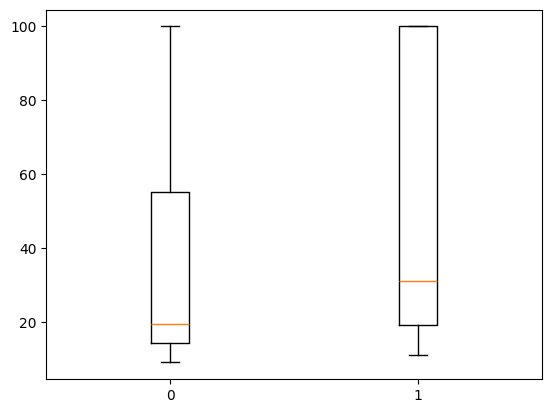

In [147]:
plt.boxplot([load_cuts, raw_cuts], positions=[0, 1])
plt.show()

## Summary

- loading model with cutting planes from 0 optimization seems to slightly reduce cutting planes needed for k_reg optimization
- hard to tell as even repeated runs of same optimization can vary the number of cuts